In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
df = pd.read_csv('HousingData.csv')

In [23]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [24]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [25]:
df.isna().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [26]:
df.shape

(506, 14)

In [27]:
df['AGE'] = df['AGE'].fillna(df['AGE'].mean())


In [28]:
df['AGE'].isna().sum()

np.int64(0)

In [29]:
med_col= ['CRIM','INDUS','CHAS','LSTAT']
df[med_col] = df[med_col].fillna(df[med_col].mean())

In [30]:
df.isna().sum()

,0
CRIM,0
ZN,20
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [31]:
df['ZN'] = df['ZN'].fillna(df['ZN'].mean())


In [32]:
df.shape

(506, 14)

In [33]:
df.duplicated().sum()

np.int64(0)

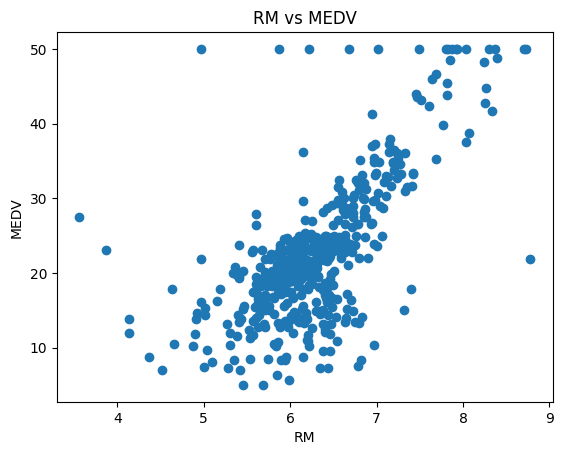

In [34]:
plt.scatter(df['RM'], df['MEDV'])
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.title('RM vs MEDV')
plt.show()


In [35]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [36]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [37]:
y_pred = model.predict(X_test)
print("Prediction",y_pred)

Prediction [ 2.91432496e+01  3.65356675e+01  1.44925129e+01  2.50811104e+01
  1.84560923e+01  2.30104937e+01  1.81386861e+01  1.46265167e+01
  2.21158938e+01  2.08706364e+01  2.50758640e+01  1.87470982e+01
 -5.67498472e+00  2.17286655e+01  1.90464014e+01  2.54293420e+01
  1.96620047e+01  6.12420178e+00  4.09972355e+01  1.72352716e+01
  2.48905259e+01  3.02961849e+01  1.18008779e+01  2.29655895e+01
  1.73451595e+01  1.51051621e+01  2.10901065e+01  1.44883316e+01
  2.30923960e+01  1.94365043e+01  2.25439953e+01  2.52375663e+01
  2.59309510e+01  1.66289054e+01  1.64513986e+01  1.66143478e+01
  3.11105960e+01  2.02837991e+01  2.43569451e+01  2.26326769e+01
  1.45257750e+01  3.23698301e+01  4.30428488e+01  1.76390763e+01
  2.76326197e+01  1.64305143e+01  1.42484248e+01  2.61635938e+01
  1.97678160e+01  3.01463483e+01  2.09688785e+01  3.38338873e+01
  1.64161397e+01  2.63964842e+01  3.97974153e+01  2.20563187e+01
  1.86348862e+01  3.28326904e+01  2.54125467e+01  1.30089663e+01
  2.27876091e+

In [38]:
mae = mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error",mae)
r2_score = r2_score(y_test,y_pred)
print("R2 Score",r2_score)

Mean Absolute Error 3.1499233573457692
R2 Score 0.6588520195508143


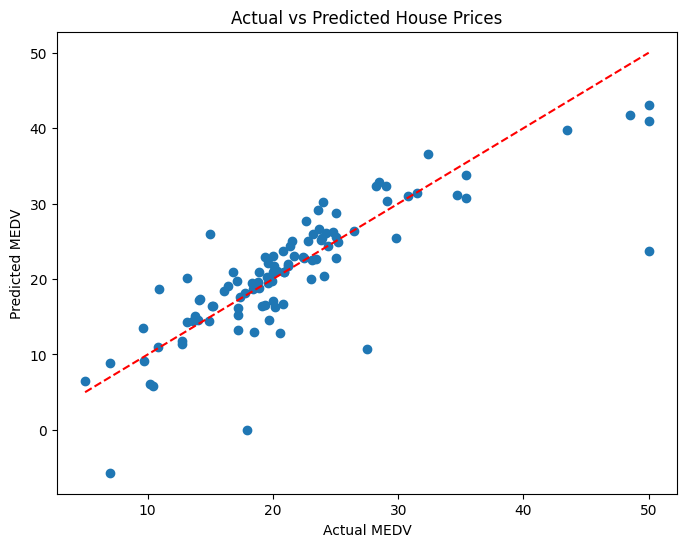

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [40]:
df.tail(1)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
505,0.04741,0.0,11.93,0.0,0.573,6.03,68.518519,2.505,1,273,21.0,396.9,7.88,11.9


In [41]:
model.predict([[0.04741,0.0,11.93,0.0,0.573,6.03,68.518519,2.505,1,273,21.0,396.9,7.88]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([22.44315864])